# Diabetes Prediction Challenge

Bu projede, Kaggle Playground Series S5E12 kapsamında verilen veri seti kullanılarak bir sınıflandırma problemi çözülmesi amaçlanmıştır. Farklı makine öğrenmesi algoritmaları eğitilerek karşılaştırılmış ve veri içerisindeki örüntüleri en iyi yakalayarak doğru tahminler yapabilen modelin geliştirilmesi hedeflenmiştir. Ayrıca, birden fazla güçlü modelin bir araya getirilmesiyle daha iyi sonuçlar elde etmek için ensemble (topluluk) yaklaşımı da uygulanmıştır.

In this project, a classification task was carried out using the dataset provided in the Kaggle Playground Series S5E12 competition. The goal was to train and compare multiple machine learning algorithms to develop a model capable of accurately capturing patterns in the data. Additionally, an ensemble approach was applied to improve performance by combining multiple strong models.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Deep Learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense

In [2]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

In [3]:
print(train.shape)
print(test.shape)

(700000, 26)
(300000, 25)


In [4]:
train.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [5]:
train.isnull().sum()

id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0


In [6]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)

### EDA

In [7]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [8]:
df.isnull().sum()

id                                         0
age                                        0
alcohol_consumption_per_week               0
physical_activity_minutes_per_week         0
diet_score                                 0
sleep_hours_per_day                        0
screen_time_hours_per_day                  0
bmi                                        0
waist_to_hip_ratio                         0
systolic_bp                                0
diastolic_bp                               0
heart_rate                                 0
cholesterol_total                          0
hdl_cholesterol                            0
ldl_cholesterol                            0
triglycerides                              0
gender                                     0
ethnicity                                  0
education_level                            0
income_level                               0
smoking_status                             0
employment_status                          0
family_his

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 26 columns):
 #   Column                              Non-Null Count    Dtype  
---  ------                              --------------    -----  
 0   id                                  1000000 non-null  int64  
 1   age                                 1000000 non-null  int64  
 2   alcohol_consumption_per_week        1000000 non-null  int64  
 3   physical_activity_minutes_per_week  1000000 non-null  int64  
 4   diet_score                          1000000 non-null  float64
 5   sleep_hours_per_day                 1000000 non-null  float64
 6   screen_time_hours_per_day           1000000 non-null  float64
 7   bmi                                 1000000 non-null  float64
 8   waist_to_hip_ratio                  1000000 non-null  float64
 9   systolic_bp                         1000000 non-null  int64  
 10  diastolic_bp                        1000000 non-null  int64  
 11  heart_rate  

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1000000.0,499999.500000,288675.278933,0.00,249999.75,499999.50,749999.25,999999.00
age,1000000.0,50.381533,11.741245,19.00,42.00,50.00,59.00,89.00
alcohol_consumption_per_week,1000000.0,2.077596,1.053658,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,1000000.0,83.866288,55.006110,1.00,49.00,72.00,100.00,748.00
diet_score,1000000.0,5.958338,1.468700,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,1000000.0,7.000878,0.905763,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,1000000.0,6.012296,2.034110,0.60,4.60,6.00,7.40,16.50
bmi,1000000.0,25.876851,2.870822,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,1000000.0,0.858838,0.038144,0.68,0.83,0.86,0.88,1.05
systolic_bp,1000000.0,116.318170,11.083525,91.00,108.00,116.00,124.00,170.00


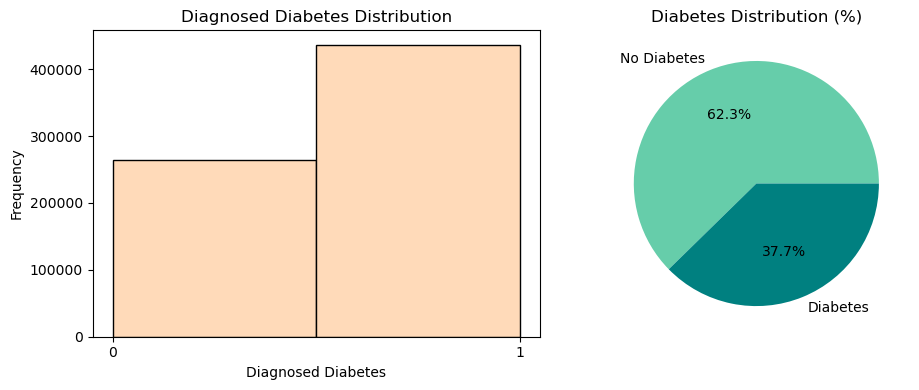

In [11]:
# Diagnosed Diabetes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['diagnosed_diabetes'].dropna(), bins=2, color='PeachPuff', edgecolor='black')
plt.xlabel('Diagnosed Diabetes')
plt.ylabel('Frequency')
plt.title('Diagnosed Diabetes Distribution')
plt.xticks([0, 1])

plt.subplot(1, 2, 2)
diabetes_counts = df['diagnosed_diabetes'].value_counts()
plt.pie(diabetes_counts, labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%', colors=['MediumAquaMarine', 'Teal'])
plt.title('Diabetes Distribution (%)')
plt.tight_layout()
plt.show()

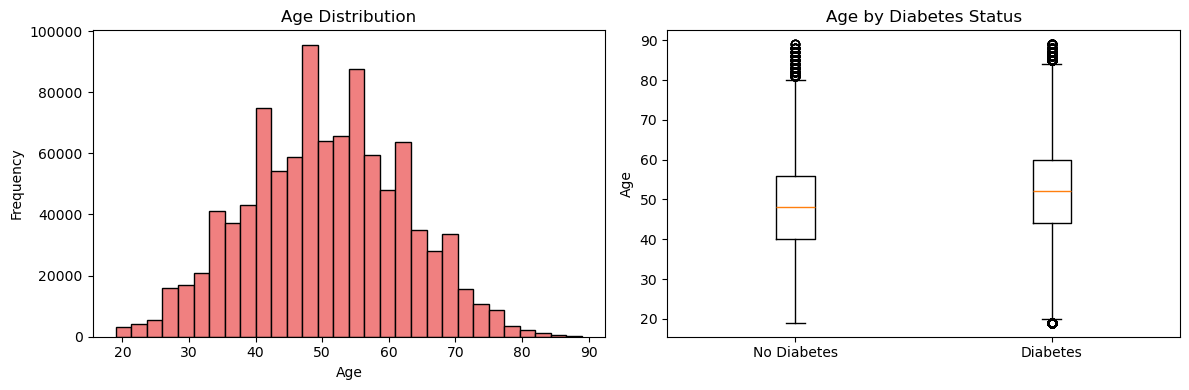

In [12]:
# Age.Distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['age'], bins=30, color='lightcoral', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
plt.boxplot([df[df['diagnosed_diabetes'] == 0]['age'].dropna(), 
             df[df['diagnosed_diabetes'] == 1]['age'].dropna()],
            labels=['No Diabetes', 'Diabetes'])
plt.ylabel('Age')
plt.title('Age by Diabetes Status')
plt.tight_layout()
plt.show()

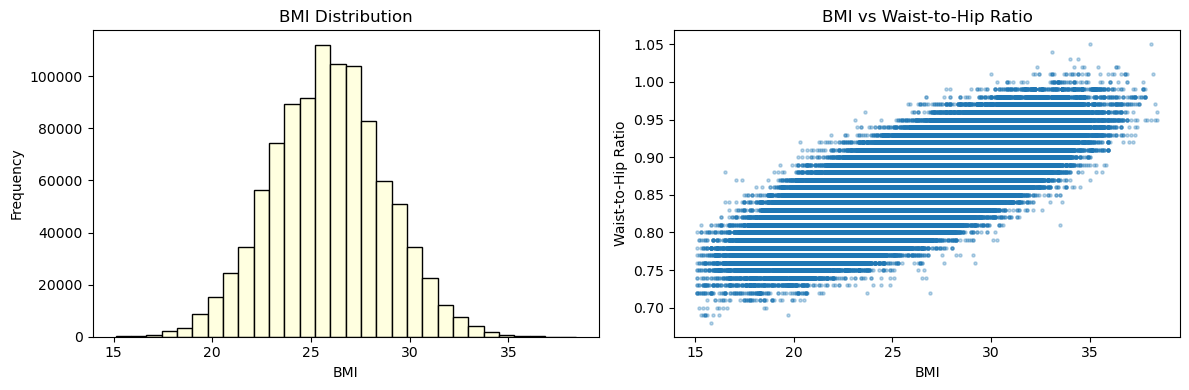

In [13]:
# BMI ve Waist-to-Hip Ratio dağılımı
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['bmi'], bins=30, color='lightyellow', edgecolor='black')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('BMI Distribution')

plt.subplot(1, 2, 2)
plt.scatter(df['bmi'], df['waist_to_hip_ratio'], alpha=0.3, s=5)
plt.xlabel('BMI')
plt.ylabel('Waist-to-Hip Ratio')
plt.title('BMI vs Waist-to-Hip Ratio')

plt.tight_layout()
plt.show()

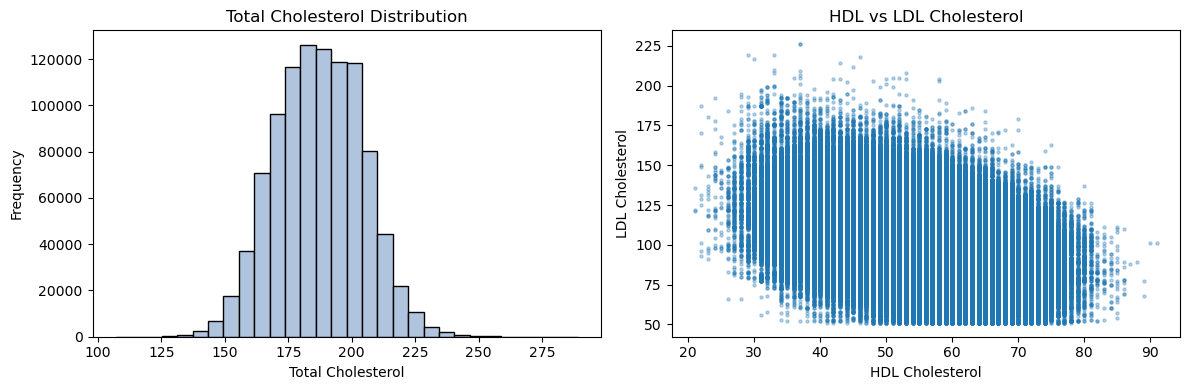

In [14]:
# Kolesterol seviyeleri
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['cholesterol_total'], bins=30, color='lightsteelblue', edgecolor='black')
plt.xlabel('Total Cholesterol')
plt.ylabel('Frequency')
plt.title('Total Cholesterol Distribution')

plt.subplot(1, 2, 2)
plt.scatter(df['hdl_cholesterol'], df['ldl_cholesterol'], alpha=0.3, s=5)
plt.xlabel('HDL Cholesterol')
plt.ylabel('LDL Cholesterol')
plt.title('HDL vs LDL Cholesterol')

plt.tight_layout()
plt.show()

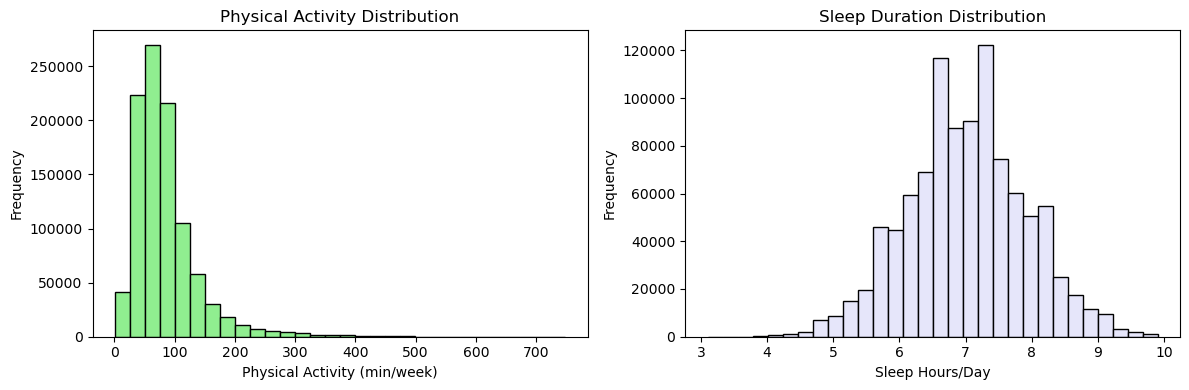

In [15]:
# Yaşam tarzı faktörleri
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['physical_activity_minutes_per_week'], bins=30, color='lightgreen', edgecolor='black')
plt.xlabel('Physical Activity (min/week)')
plt.ylabel('Frequency')
plt.title('Physical Activity Distribution')

plt.subplot(1, 2, 2)
plt.hist(df['sleep_hours_per_day'], bins=30, color='lavender', edgecolor='black')
plt.xlabel('Sleep Hours/Day')
plt.ylabel('Frequency')
plt.title('Sleep Duration Distribution')

plt.tight_layout()
plt.show()

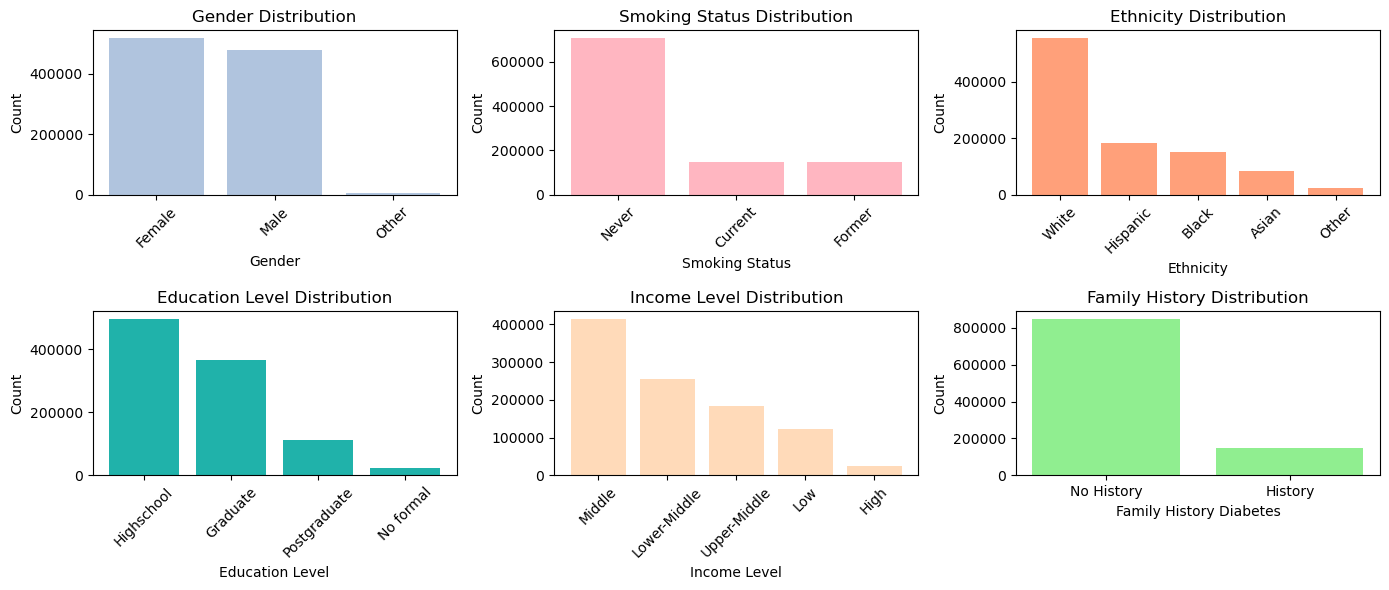

In [16]:
# Kategorik değişkenlerin dağılımı
plt.figure(figsize=(14, 6))

plt.subplot(2, 3, 1)
plt.bar(df['gender'].value_counts().index, df['gender'].value_counts().values, color='LightSteelBlue')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
plt.bar(df['smoking_status'].value_counts().index, df['smoking_status'].value_counts().values, color='lightpink')
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Smoking Status Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 3)
plt.bar(df['ethnicity'].value_counts().index, df['ethnicity'].value_counts().values, color='LightSalmon')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.title('Ethnicity Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 4)
plt.bar(df['education_level'].value_counts().index, df['education_level'].value_counts().values, color='lightseagreen')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.title('Education Level Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 5)
plt.bar(df['income_level'].value_counts().index, df['income_level'].value_counts().values, color='peachpuff')
plt.xlabel('Income Level')
plt.ylabel('Count')
plt.title('Income Level Distribution')
plt.xticks(rotation=45)

plt.subplot(2, 3, 6)
plt.bar(['No History', 'History'], [
    (df['family_history_diabetes'] == 0).sum(),
    (df['family_history_diabetes'] == 1).sum()], color='LightGreen')
plt.xlabel('Family History Diabetes')
plt.ylabel('Count')
plt.title('Family History Distribution')

plt.tight_layout()
plt.show()


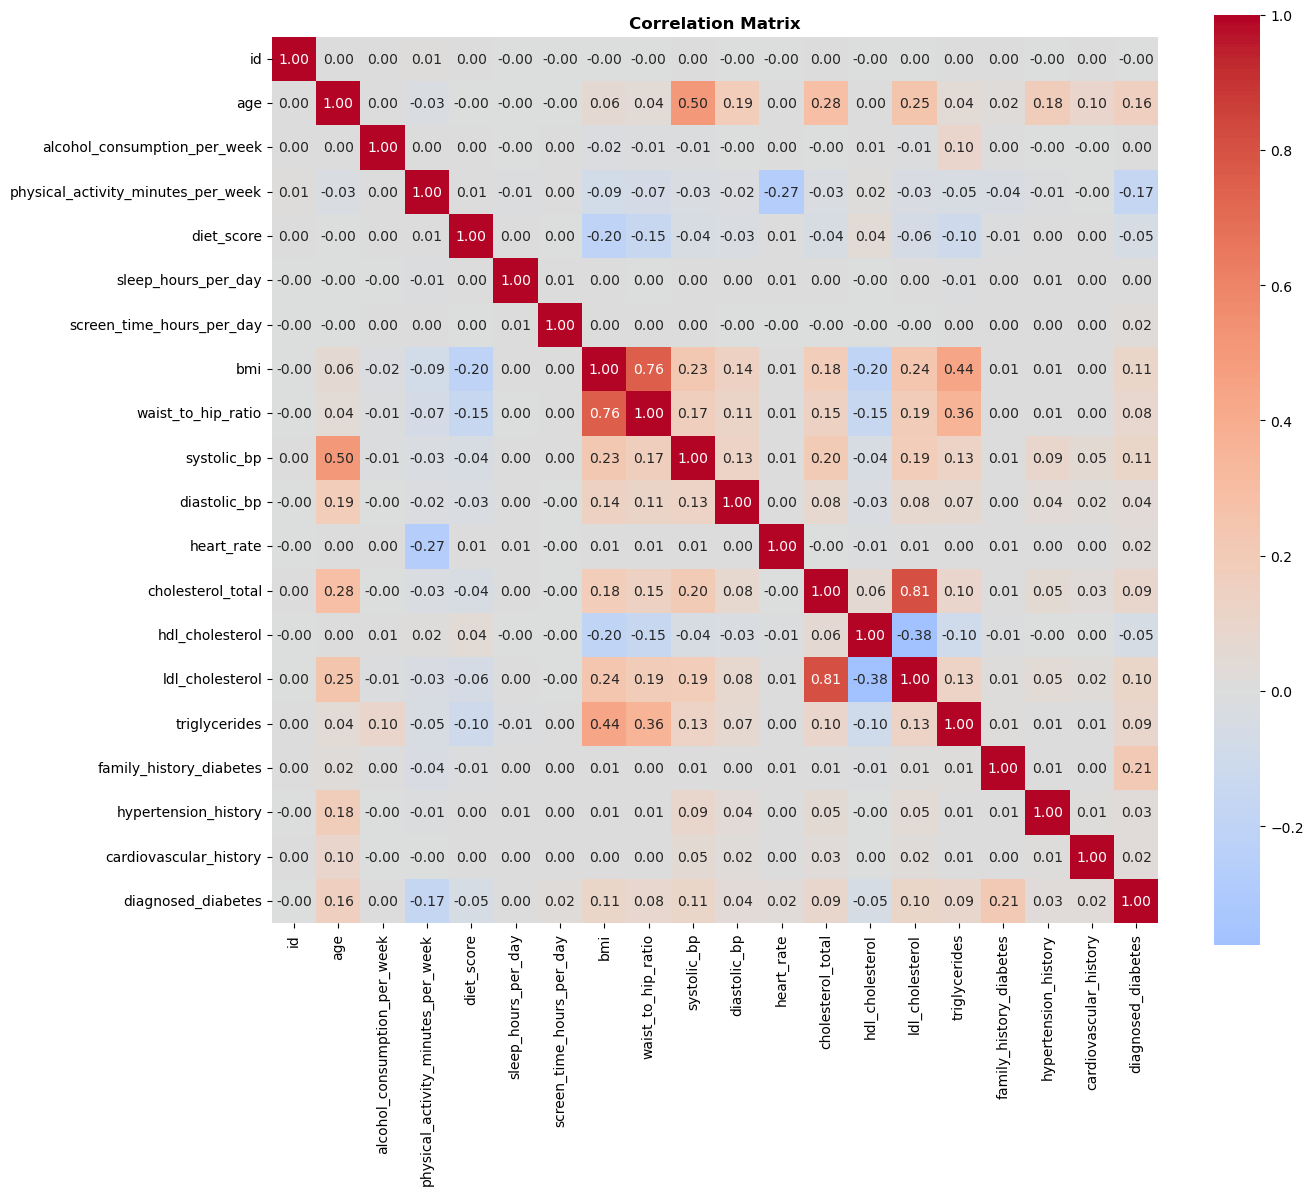

In [17]:
#Correlation Matrix
plt.figure(figsize=(14, 12))
correlation_matrix = train.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
#Correlation by diagnosed_diabetes
abs(df.corr(numeric_only=True))['diagnosed_diabetes'].sort_values(ascending=False)

diagnosed_diabetes                    1.000000
family_history_diabetes               0.211064
physical_activity_minutes_per_week    0.169789
age                                   0.161162
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
hdl_cholesterol                       0.053231
diet_score                            0.050119
diastolic_bp                          0.036271
hypertension_history                  0.029979
cardiovascular_history                0.024746
heart_rate                            0.023865
screen_time_hours_per_day             0.018213
sleep_hours_per_day                   0.003509
alcohol_consumption_per_week          0.002991
id                                    0.000075
Name: diagnosed_diabetes, dtype: float64

In [19]:
df.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


### Feature Engineering

In [8]:
# Smoking
smoking_map = {'Never': 0, 'Former': 1, 'Current': 2}
df['smoking'] = df['smoking_status'].map(smoking_map)

# Gender
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

# Education level
education_map = {
    'No formal': 0, 
    'Highschool': 1, 
    'Graduate': 2, 
    'Postgraduate': 3
}
df['education_level'] = df['education_level'].map(education_map)

# Income level
income_map = {
    'Low': 0,
    'Lower-Middle': 1,
    'Middle': 2,
    'Upper-Middle': 3
}
df['income_level'] = df['income_level'].map(income_map)

# Employment stayus
employment_map = {
    'Student': 0,
    'Employed': 1,
    'Retired': 2
}
df['employment_status'] = df['employment_status'].map(employment_map)

In [9]:
# Physical_activity
df['activity_category'] = pd.cut(df['physical_activity_minutes_per_week'], 
                                  bins=[-1, 30, 75, 150, 750],
                                  labels=['Sedentary', 'Low', 'Moderate', 'High'])

In [10]:
# Mtabolic_score (BMI ve WHR combinition)
# Normalize et: 0-100 arası (düşük=sağlıklı, yüksek=risky)
df['metabolic_score'] = ((df['bmi'] - df['bmi'].min()) / (df['bmi'].max() - df['bmi'].min()) * 50 +
                         (df['waist_to_hip_ratio'] - df['waist_to_hip_ratio'].min()) / 
                         (df['waist_to_hip_ratio'].max() - df['waist_to_hip_ratio'].min()) * 50)

# Nutrition quality (diet_score: yüksek=iyi, 0.1-9.9 range)
df['good_diet'] = (df['diet_score'] >= 6).astype(int)

In [11]:
# Yaş × BMI (yaşla birlikte yüksek BMI)
df['age_bmi_interaction'] = df['age'] * df['bmi'] / 100

# Yaş × Fiziksel Aktivite (yaşlılarda aktivite daha önemli)
df['age_activity_interaction'] = df['age'] * (df['physical_activity_minutes_per_week'] / 100)

# BMI × Kardiyovasküler faktörler
df['bmi_bp_interaction'] = (df['bmi'] / 25) * (df['systolic_bp'] / 120)

In [12]:
# Kan basıncı kategorileri (ACC/AHA guidelines)
df['bp_category'] = pd.cut(df['systolic_bp'], 
                            bins=[0, 120, 130, 140, 200],
                            labels=['Normal', 'Elevated', 'High1', 'High2'])

# Nabız basıncı (pulse pressure = Systolic - Diastolic)
# Yüksek pulse pressure = arter riski
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

In [13]:
# LDL/HDL rate (yüksek=risk)
df['ldl_hdl_ratio'] = df['ldl_cholesterol'] / (df['hdl_cholesterol'] + 1)

# Trigliserit/HDL rate (metabolik sendrom göstergesi)
df['trig_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 1)

In [14]:
abs(df.corr(numeric_only=True))['diagnosed_diabetes'].sort_values(ascending=False)

diagnosed_diabetes                    1.000000
family_history_diabetes               0.211064
age_bmi_interaction                   0.184644
physical_activity_minutes_per_week    0.169789
age                                   0.161162
bmi_bp_interaction                    0.135143
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
age_activity_interaction              0.101848
metabolic_score                       0.100667
trig_hdl_ratio                        0.098769
ldl_hdl_ratio                         0.094588
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
pulse_pressure                        0.076650
hdl_cholesterol                       0.053231
diet_score                            0.050119
good_diet                             0.046595
diastolic_bp                          0.036271
hypertension_

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 37 columns):
 #   Column                              Non-Null Count    Dtype   
---  ------                              --------------    -----   
 0   id                                  1000000 non-null  int64   
 1   age                                 1000000 non-null  int64   
 2   alcohol_consumption_per_week        1000000 non-null  int64   
 3   physical_activity_minutes_per_week  1000000 non-null  int64   
 4   diet_score                          1000000 non-null  float64 
 5   sleep_hours_per_day                 1000000 non-null  float64 
 6   screen_time_hours_per_day           1000000 non-null  float64 
 7   bmi                                 1000000 non-null  float64 
 8   waist_to_hip_ratio                  1000000 non-null  float64 
 9   systolic_bp                         1000000 non-null  int64   
 10  diastolic_bp                        1000000 non-null  int64   
 11 

In [28]:
top_features = [
    'family_history_diabetes',
    'age_bmi_interaction',
    'physical_activity_minutes_per_week',
    'age',
    'bmi_bp_interaction',
    'systolic_bp',
    'bmi',
    'ldl_cholesterol',
    'age_activity_interaction',
    'metabolic_score', #
    'trig_hdl_ratio',
    'ldl_hdl_ratio',
    'triglycerides',
    'cholesterol_total',
    'waist_to_hip_ratio',
    'ethnicity',
    'activity_category',
    'bp_category'
]

In [29]:
train_df = df[df['diagnosed_diabetes'].notna()]
test_df  = df[df['diagnosed_diabetes'].isna()]

In [30]:
x = train_df[top_features]
y = train_df['diagnosed_diabetes']

x_final_test = test_df[top_features]

In [31]:
x_all = pd.concat([x, x_final_test])
x_all = pd.get_dummies(x_all, drop_first=True)

In [32]:
x = x_all.iloc[:len(x)]
x_final_test = x_all.iloc[len(x):]

### Model Training & Benchmarking

In [33]:
r=RandomForestClassifier()
g=GradientBoostingClassifier()

In [34]:
x_train,x_test, y_train, y_test=train_test_split(x,y, random_state=42, test_size=0.20)

In [35]:
r.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
tahmin_r=r.predict(x_test)

In [37]:
accuracy_score(tahmin_r, y_test)

0.6614071428571429

In [38]:
g.fit(x_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [39]:
tahmin_g=g.predict(x_test) 

In [40]:
accuracy_score(tahmin_g, y_test)

0.6692857142857143

In [41]:
roc_auc_score(y_test, tahmin_g)

0.6067986818369242

In [42]:
b = BernoulliNB()
l = LogisticRegression()
d = DecisionTreeClassifier()
r = RandomForestClassifier()
gb= GradientBoostingClassifier()
kn= KNeighborsClassifier()
ab= AdaBoostClassifier()
mn= MultinomialNB()

def algo_test(x, y):
    modeller=[ b, l, d, r, gb, kn, ab, mn]
    isimler=["BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
             "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
             "AdaBoostClassifier", "MultinomialNB"]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state = 42)
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    mdl=[]

    print("Veriler hazır modeller deneniyor")
    for model in modeller:
        print(model, " modeli eğitiliyor!..")
        model=model.fit(x_train,y_train)
        tahmin=model.predict(x_test)
        mdl.append(model)
        accuracy.append(accuracy_score(y_test, tahmin))
        precision.append(precision_score(y_test, tahmin, average="micro"))
        recall.append(recall_score(y_test, tahmin, average="micro"))
        f1.append(f1_score(y_test, tahmin, average="micro"))
        print(confusion_matrix(y_test, tahmin))

    print("Eğitim tamamlandı.")
    
    metrics=pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1", "Model"], index=isimler)
    metrics["Accuracy"] = accuracy
    metrics["Precision"] = precision  
    metrics["Recall"] = recall
    metrics["F1"] = f1
    metrics["Model"]=mdl

    metrics.sort_values("F1", ascending=False, inplace=True)

    print("En başarılı model: ", metrics.iloc[0].name)
    model=metrics.iloc[0,-1]
    tahmin=model.predict(np.array(x_test) if model==kn else x_test)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("classification Report:")
    print(classification_report(y_test, tahmin))
    print("Diğer Modeller:")
    
    return metrics.drop("Model", axis=1)

In [43]:
algo_test(x,y)

Veriler hazır modeller deneniyor
BernoulliNB()  modeli eğitiliyor!..
[[20089 32540]
 [17548 69823]]
LogisticRegression()  modeli eğitiliyor!..
[[17926 34703]
 [12841 74530]]
DecisionTreeClassifier()  modeli eğitiliyor!..
[[24439 28190]
 [29504 57867]]
RandomForestClassifier()  modeli eğitiliyor!..
[[20593 32036]
 [15280 72091]]
GradientBoostingClassifier()  modeli eğitiliyor!..
[[18683 33946]
 [12353 75018]]
KNeighborsClassifier()  modeli eğitiliyor!..
[[19520 33109]
 [22801 64570]]
AdaBoostClassifier()  modeli eğitiliyor!..
[[18158 34471]
 [12908 74463]]
MultinomialNB()  modeli eğitiliyor!..
[[24200 28429]
 [26134 61237]]
Eğitim tamamlandı.
En başarılı model:  GradientBoostingClassifier
Confusion Matrix:
[[18683 33946]
 [12353 75018]]
classification Report:
              precision    recall  f1-score   support

         0.0       0.60      0.35      0.45     52629
         1.0       0.69      0.86      0.76     87371

    accuracy                           0.67    140000
   macro avg 

,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.669293,0.669293,0.669293,0.669293
RandomForestClassifier,0.662029,0.662029,0.662029,0.662029
AdaBoostClassifier,0.661579,0.661579,0.661579,0.661579
LogisticRegression,0.660400,0.660400,0.660400,0.660400
BernoulliNB,0.642229,0.642229,0.642229,0.642229
MultinomialNB,0.610264,0.610264,0.610264,0.610264
KNeighborsClassifier,0.600643,0.600643,0.600643,0.600643
DecisionTreeClassifier,0.587900,0.587900,0.587900,0.587900


In [51]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler

def advanced_classification_test(x, y):
    
    # Scaling
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x)
    
    # Train-test split
    x_train, x_test, y_train, y_test = train_test_split(
        x_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Modeller (CatBoost'u çıkardım)
    models = {
        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.9,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ),
        "LightGBM": LGBMClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            random_state=42,
            verbose=-1
        ),
        "Voting Ensemble (XGB + LGB)": VotingClassifier(
            estimators=[
                ('xgb', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')),
                ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
            ],
            voting='soft'
        )
    }
    
    results = []
    
    for name, model in models.items():
        print(f"Training {name}...")
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
        proba = model.predict_proba(x_test)[:, 1]
        
        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1": f1_score(y_test, preds, zero_division=0),
            "AUC": roc_auc_score(y_test, proba)
        })
    
    result = pd.DataFrame(results)
    result = result.sort_values(by="AUC", ascending=False).reset_index(drop=True)
    
    return result

result = advanced_classification_test(x, y)
print(result)

Training XGBoost...
Training LightGBM...
Training Voting Ensemble (XGB + LGB)...
                         Model  Accuracy  Precision    Recall        F1  \
0  Voting Ensemble (XGB + LGB)  0.682436   0.706219  0.839894  0.767278   
1                     LightGBM  0.679793   0.700253  0.850197  0.767974   
2                      XGBoost  0.679550   0.700615  0.848420  0.767466   

        AUC  
0  0.723131  
1  0.719176  
2  0.718930  


In [52]:
best_model = VotingClassifier(
            estimators=[
                ('xgb', XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')),
                ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
            ],
            voting='soft'
        )

best_model.fit(x, y)
prediction= best_model.predict(x_test)

In [53]:
prediction_final = best_model.predict(x_final_test)

In [54]:
sonuc = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': prediction_final
})

In [55]:
sonuc

,id,diagnosed_diabetes
0,700000,0.0
1,700001,1.0
2,700002,1.0
3,700003,0.0
4,700004,1.0
...,...,...
299995,999995,1.0
299996,999996,1.0
299997,999997,0.0
299998,999998,1.0


In [56]:
#Şimdi csv olarak kaydediyoruz
sonuc.to_csv('submission.csv', index=False)

In [57]:
import pickle
import joblib

# ============================================
# 1. PICKLE İLE KAYDET
# ============================================

# Model'i kaydet
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Scaler'ı kaydet
scaler = StandardScaler()
scaler.fit(x_train)  

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Feature names'i kaydet
with open('top_features.pkl', 'wb') as f:
    pickle.dump(top_features, f)

print("✅ Pickle ile kaydedildi")

# ============================================
# 2. JOBLIB İLE KAYDET (Tavsiye edilen)
# ============================================

joblib.dump(best_model, 'model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(top_features, 'top_features.joblib')

print("✅ Joblib ile kaydedildi")

✅ Pickle ile kaydedildi
✅ Joblib ile kaydedildi


Elde edilen sonuçlara göre, Voting Ensemble yöntemi en iyi genel performansı göstermiştir. XGBoost, LightGBM ve CatBoost modellerinin birleştirilmesiyle oluşturulan bu yapı, yaklaşık %68 doğruluk ve daha yüksek recall (~%84) değeri ile diğer tekil modellerden daha dengeli sonuçlar üretmiştir. Özellikle recall ve F1 skorlarının yüksek olması, modelin pozitif sınıfı yakalama konusunda başarılı olduğunu göstermektedir. Genel olarak, soft voting ensemble yaklaşımının tekil modellere kıyasla performansı artırdığı gözlemlenmiştir.

According to the results, the Voting Ensemble model achieved the best overall performance. By combining XGBoost, LightGBM, and CatBoost using a soft voting strategy, the model reached approximately 68% accuracy and a higher recall (~84%), producing more balanced results than individual models. The relatively high recall and F1 scores indicate strong performance in identifying the positive class. Overall, the ensemble approach outperformed the individual models.